In [1]:
import random
import sys
from typing import Collection

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import Tensor
from tqdm import tqdm

sys.path.insert(0, "..")
from src.simulator.cache_simulator import PageLRUCache
from jaxtyping import Float, Int
from collections import defaultdict
from copy import deepcopy
from dqntrainer import DQNTrainer

In [2]:
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
print(f'Using device {device}')

rng = random.Random()

Using device cuda


In [3]:
dfs: list[pd.DataFrame] = []
for i in range(1, 23):
    df = pd.read_csv(f'../page_access/tpch/q{i}.csv')
    df['query'] = i
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

queries: list[list[tuple[str, int]]] = [
    list(zip(g['table'], g['block']))
    for _, g in df.groupby('query')
]
query_id_map = {idx: query for idx, query in enumerate(queries)}

TARGET_COLS = 1000

table2n_blocks: dict[str, int] = {}
for group in queries:
    for table, block in group:
        table2n_blocks[table] = max(table2n_blocks.get(table, 0), block + 1)

tables = table2n_blocks.keys()

In [4]:
N_EPISODES = 50
dqn_trainer = DQNTrainer(
    table2n_blocks=table2n_blocks,
    query_id_map=query_id_map,
    target_cols=1000,
    rng=rng,
)
dqn, log = dqn_trainer.train(
    update_steps=2,
    epsilon_schedule=np.geomspace(0.9, 0.01, num=N_EPISODES),
    gamma=0.9,
    tau=0.1,
    history_size=100,
    mini_batch_size=None,
    cache_capacity_pages=2000,
    device=device,
)

Episode 49/49: 100%|██████████| 50/50 [29:42<00:00, 35.64s/it, loss=4.6185e+00]                             


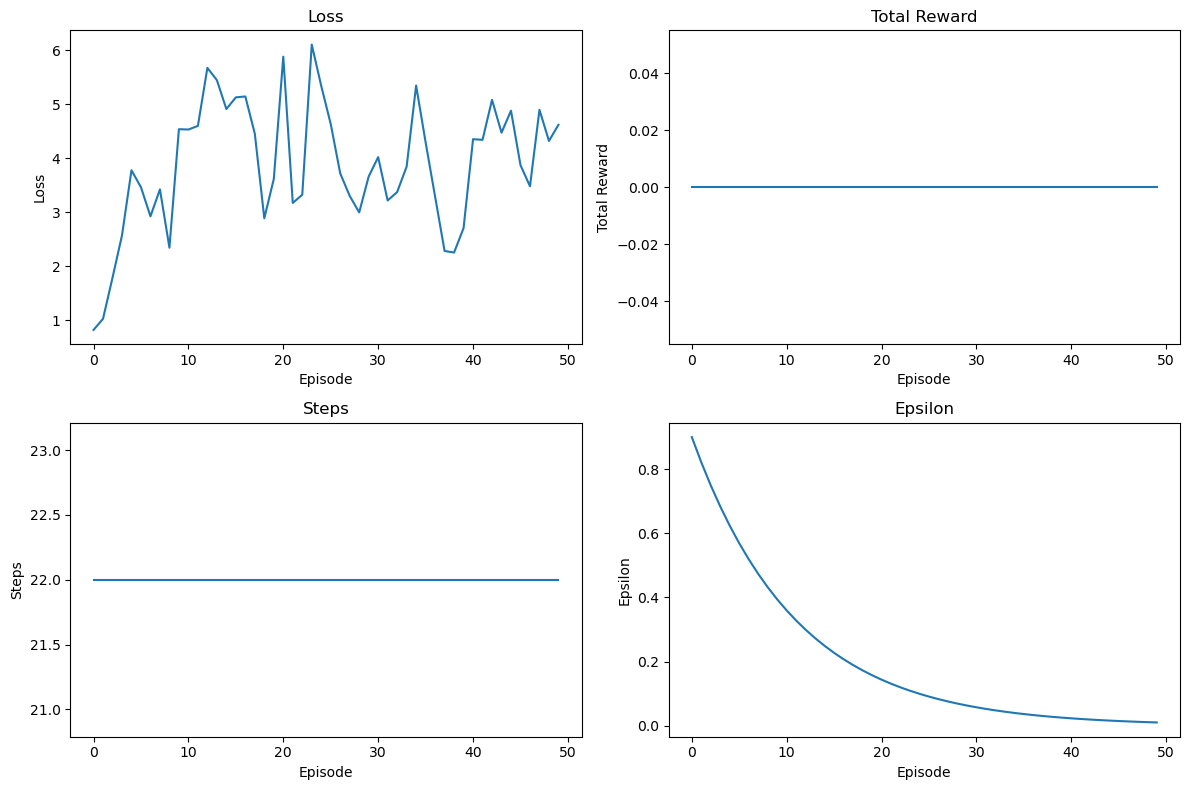

In [ ]:
episodes = np.arange(len(log.episode_mean_loss))
mean = np.array(log.episode_mean_loss)
std = np.array(log.episode_std_loss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Episode-level: mean ± 1 std
ax = axes[0]
ax.plot(episodes, mean, label="Mean loss")
ax.fill_between(episodes, mean - std, mean + std, alpha=0.25, label="±1 std")
ax.set(xlabel="Episode", ylabel="Loss", title="Loss per Episode")
ax.legend()

# Global step-level loss
ax = axes[1]
ax.plot(log.step_loss, linewidth=0.5, alpha=0.6)
ax.set(xlabel="Step (global)", ylabel="Loss", title="Loss per Step")

fig.tight_layout()
plt.show()

In [6]:
dqn.cpu()
input_size = dqn.net[0].in_features
dummy_input = torch.zeros(1, input_size)
torch.onnx.export(
    dqn,
    (dummy_input,),
    'dqn.onnx',
    input_names=['state'],
    output_names=['q_value'],
    dynamic_axes={'state': {0: 'batch_size'}}  # allows variable batch size
)